# IDX Exchange Data Science

In [4]:
#import packages
from pathlib import Path
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Overview
### Loading data

In [5]:
# Locate data whether the kernel starts in the project root or notebooks/.
cwd = Path.cwd()
project_root = next(
    (parent for parent in (cwd, *cwd.parents)
     if (parent / "notebooks" / "01_exploration.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Cannot locate the project root from {cwd}")

data_dir = project_root / "data"
files = sorted(
    f for f in data_dir.glob("*")
    if f.is_file() and f.suffix.lower() == ".csv"
    and f.name.lower().startswith("crmlssold")
)
print(f"Found {len(files)} files in {data_dir}")
if not files:
    raise FileNotFoundError(
        f"No CRMLSSold*.csv files found in {data_dir}. "
        "Check that the downloaded files are in this folder."
    )

# Read each file once and keep the individual dataframes.
dfs = {}
for f in files:
    dfs[f.stem] = pd.read_csv(f, low_memory=False)
    print(f"{f.name}: {dfs[f.stem].shape}")

# Combine the loaded dataframes and record each row's source file.
df_all = pd.concat(
    (dfs[f.stem].assign(source_file=f.name) for f in files),
    ignore_index=True,
)
print(df_all.shape)


Found 6 files in /Users/daira/IDX-Exchange-Data-Science/data
CRMLSSold202511.csv: (19088, 78)
CRMLSSold202512.csv: (20538, 78)
CRMLSSold202601.csv: (16487, 78)
CRMLSSold202602.csv: (19010, 80)
CRMLSSold202603.csv: (23372, 80)
CRMLSSold202604.csv: (24261, 80)
(122756, 81)


In [6]:
df_all.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122756 entries, 0 to 122755
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 117091 non-null  object 
 1   ListAgentAOR                  122713 non-null  object 
 2   Flooring                      71285 non-null   object 
 3   ViewYN                        110638 non-null  object 
 4   WaterfrontYN                  73 non-null      object 
 5   BasementYN                    1969 non-null    object 
 6   PoolPrivateYN                 109340 non-null  object 
 7   OriginalListPrice             122388 non-null  float64
 8   ListingKey                    122756 non-null  int64  
 9   ListAgentEmail                122453 non-null  object 
 10  CloseDate                     122756 non-null  object 
 11  ClosePrice                    122754 non-null  float64
 12  ListAgentFirstName            122257 non-nul

### Querying data to scope of the project

In [7]:
#Querying to restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc)
df_filtered = df_all.query("PropertyType == 'Residential' and PropertySubType == 'SingleFamilyResidence'")
df_filtered.head(10)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file,OriginatingSystemName,OriginatingSystemSubName
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv,NaN,NaN
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv,NaN,NaN
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv,NaN,NaN
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv,NaN,NaN
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv,NaN,NaN
5,LakeCounty,LakeCounty,Vinyl,True,NaN,NaN,False,325000.0,1147188566,sarahdhomes4sale@gmail.com,...,False,2.0,Konocti Unified,95423,0.0,36590.0,NaN,CRMLSSold202511.csv,NaN,NaN
7,PacificWest,PacificWest,NaN,True,NaN,NaN,True,985000.0,1147186097,kari@thedelaneyteam.com,...,False,2.0,Tustin Unified,92780,0.0,7200.0,NaN,CRMLSSold202511.csv,NaN,NaN
9,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,NaN,False,NaN,NaN,False,1700000.0,1147177566,laura@themorenogroupla.com,...,False,NaN,NaN,90025,NaN,7377.0,NaN,CRMLSSold202511.csv,NaN,NaN
11,SanDiego,SanDiego,NaN,False,NaN,NaN,False,875000000.0,1147175914,peter@peterheines.com,...,False,3.0,NaN,92064,NaN,NaN,NaN,CRMLSSold202511.csv,NaN,NaN
13,Southland,Southland,NaN,False,NaN,NaN,False,650000.0,1147175754,Simon@MillsRealty.com,...,False,2.0,See Remarks,91354,105.0,21475.0,NaN,CRMLSSold202511.csv,NaN,NaN


In [65]:
# Looking at the description of the filtered dataframe for ClosePrice, LivingArea, Bedrooms, Bathrooms, LotSize
df_filtered.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,6.055400e+04,6.069500e+04,6.069500e+04,60481.000000,60481.000000,60666.000000,6.069500e+04,60695.000000,0.0,0.0,...,0.0,431.000000,0.0,54463.000000,5.964500e+04,37239.000000,58354.000000,43530.000000,5.963900e+04,0.0
mean,1.375642e+06,1.142728e+09,1.320129e+06,34.698478,-118.536124,2049.765625,1.257235e+06,43.304473,NaN,NaN,...,NaN,59.754060,NaN,1.350532,1.913546e+04,2.261634,1.990815,111.650082,5.417351e+05,NaN
std,8.698125e+06,1.342866e+07,7.035355e+06,1.729267,3.581937,1037.058417,1.524326e+06,57.753111,NaN,NaN,...,NaN,240.893723,NaN,0.477141,2.041476e+05,1.418573,2.267713,373.687138,2.264818e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,0.000000,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.250000e+05,1.137048e+09,6.150000e+05,33.754468,-118.987102,1384.000000,6.190000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.357000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.950000e+05,1.146486e+09,8.790000e+05,34.075390,-118.005705,1819.000000,8.790000e+05,21.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.004000e+03,3.000000,2.000000,0.000000,7.253000e+03,NaN
75%,1.399999e+06,1.151802e+09,1.400000e+06,34.673792,-117.249165,2448.000000,1.398000e+06,57.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.820000e+03,3.000000,2.000000,135.000000,1.045400e+04,NaN
max,1.302000e+09,1.159569e+09,7.960000e+08,43.784440,120.432670,31068.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,33.000000,400.000000,20712.000000,1.938943e+09,NaN


Total rows (df_all): 122,756
Remaining rows (df_filtered): 60,695 (49.4% retained)
Rows removed by filtering: 62,061


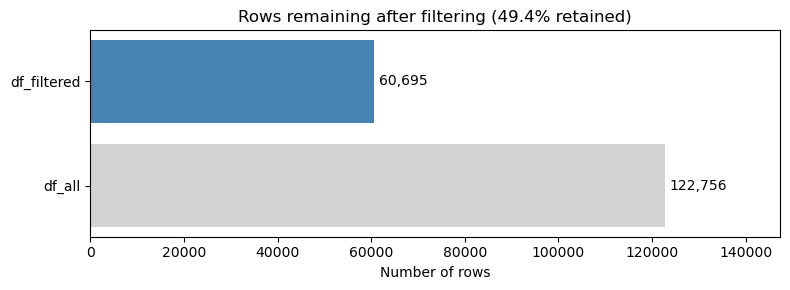

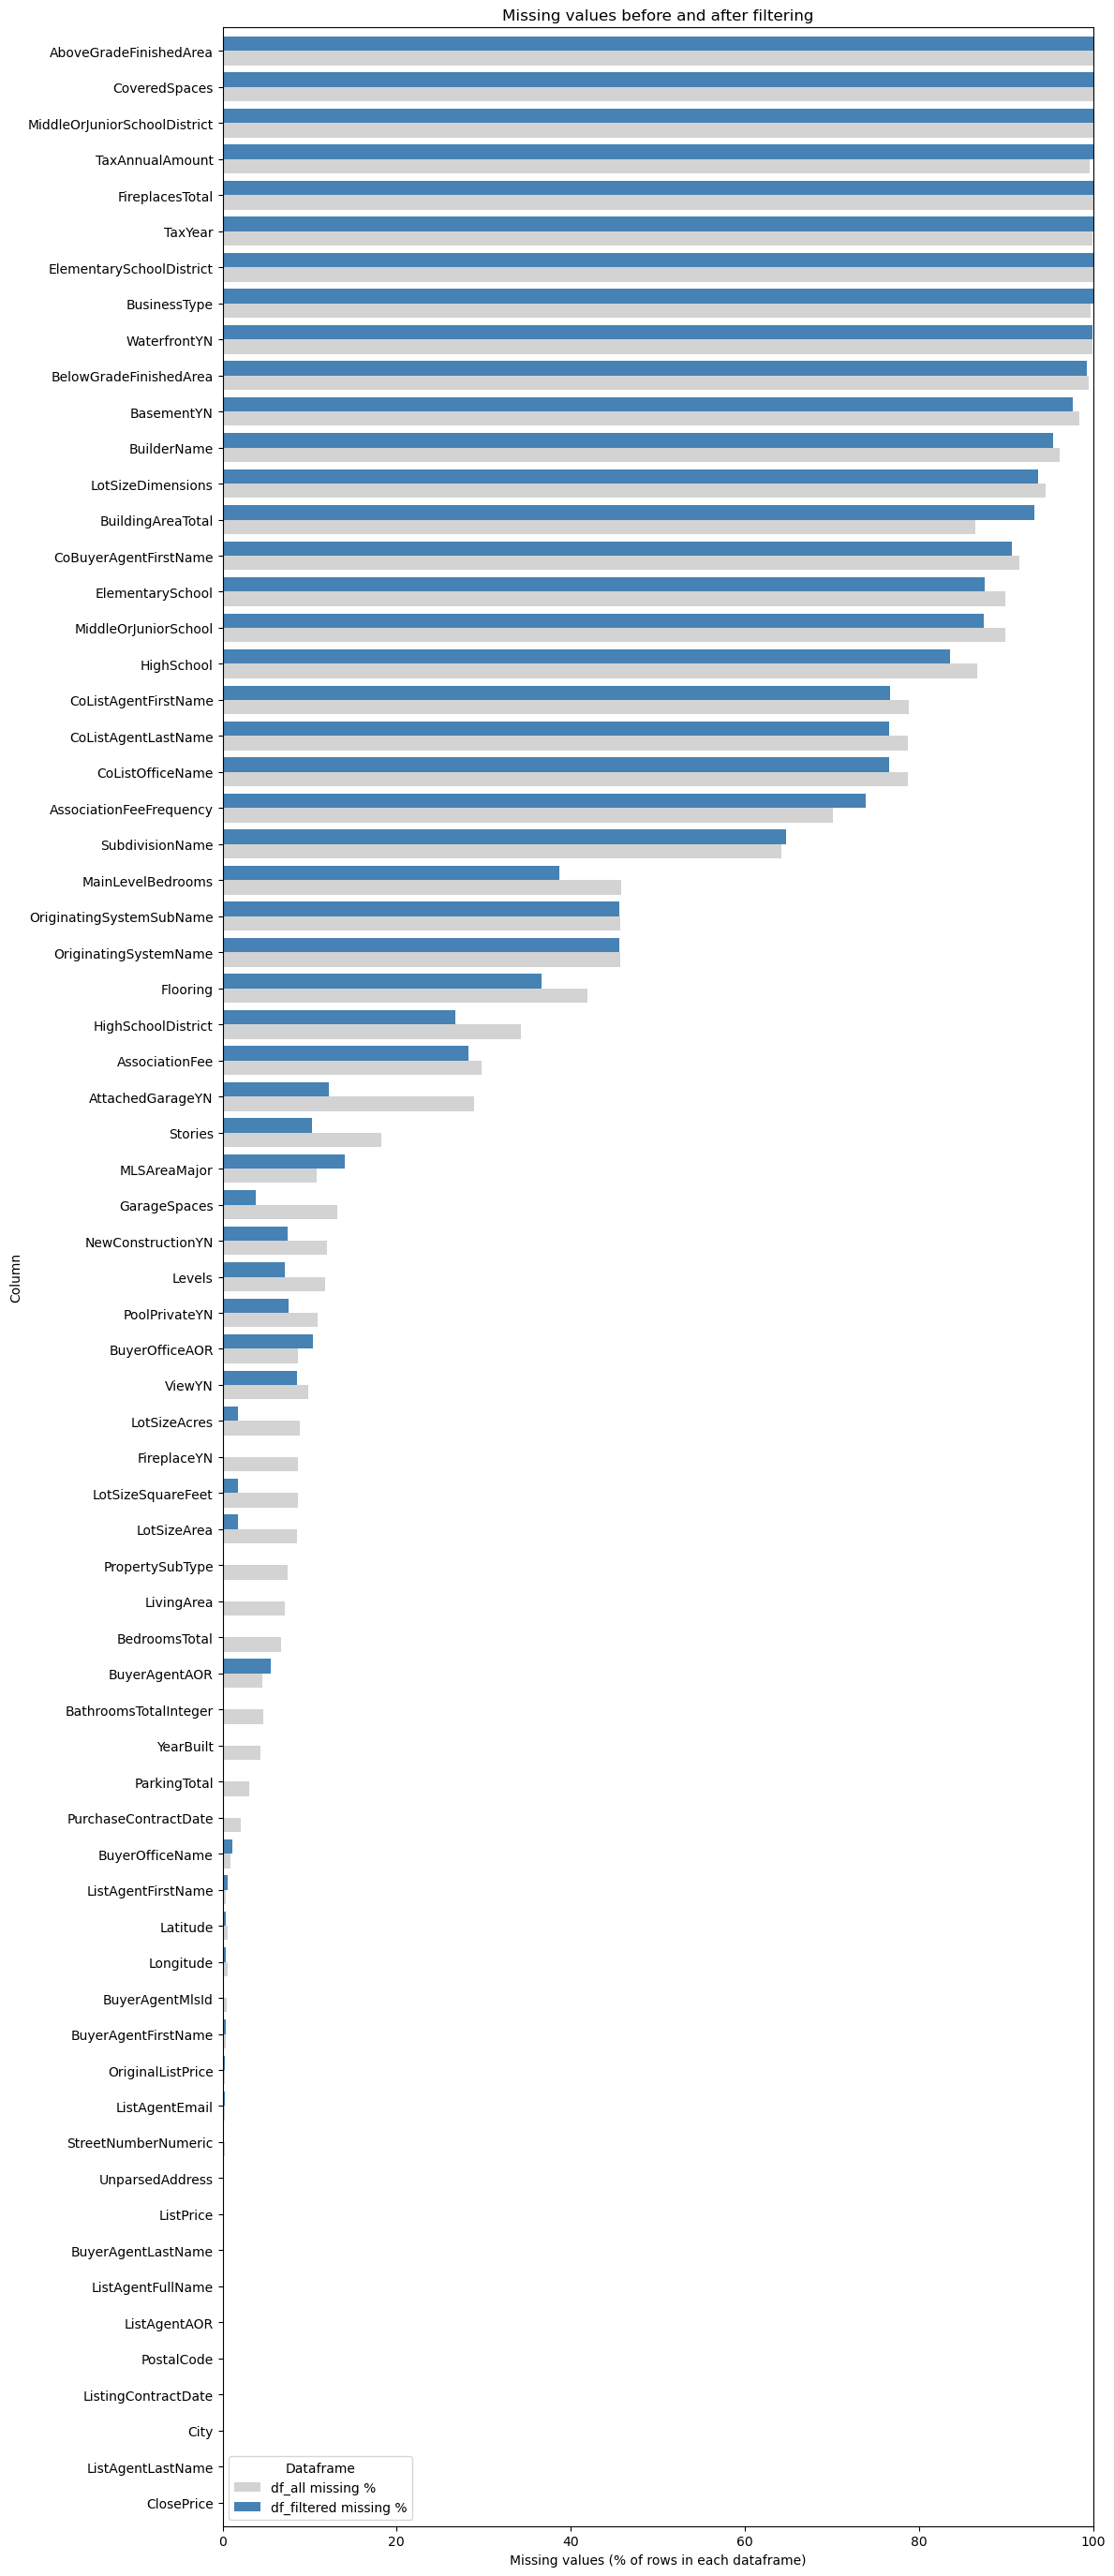

,df_all missing count,df_filtered missing count,df_all missing %,df_filtered missing %,df_filtered non-missing count
CoveredSpaces,122756,60695,100.00,100.0,0
AboveGradeFinishedArea,122756,60695,100.00,100.0,0
BusinessType,122422,60695,99.73,100.0,0
FireplacesTotal,122756,60695,100.00,100.0,0
MiddleOrJuniorSchoolDistrict,122756,60695,100.00,100.0,0
...,...,...,...,...,...
BedroomsTotal,8221,0,6.70,0.0,60695
ListingId,0,0,0.00,0.0,60695
PropertySubType,9152,0,7.46,0.0,60695
ListingKeyNumeric,0,0,0.00,0.0,60695


In [13]:
# Compare row retention and missing values before and after filtering.
import pandas as pd
import matplotlib.pyplot as plt

all_rows = len(df_all)
filtered_rows = len(df_filtered)
retained_pct = filtered_rows / all_rows * 100 if all_rows else 0
print(f"Total rows (df_all): {all_rows:,}")
print(f"Remaining rows (df_filtered): {filtered_rows:,} ({retained_pct:.1f}% retained)")
print(f"Rows removed by filtering: {all_rows - filtered_rows:,}")

missing_comparison = pd.DataFrame({
    "df_all missing count": df_all.isna().sum(),
    "df_filtered missing count": df_filtered.isna().sum(),
    "df_all missing %": df_all.isna().mean().mul(100),
    "df_filtered missing %": df_filtered.isna().mean().mul(100),
})
missing_comparison["df_filtered non-missing count"] = (
    df_filtered.notna().sum()
)
percent_columns = ["df_all missing %", "df_filtered missing %"]
chart_data = missing_comparison.loc[
    missing_comparison[percent_columns].gt(0).any(axis=1), percent_columns
]
chart_data = chart_data.loc[
    chart_data.max(axis=1).sort_values().index
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(["df_all", "df_filtered"], [all_rows, filtered_rows],
        color=["lightgray", "steelblue"])
ax.bar_label(ax.containers[0], labels=[f"{all_rows:,}", f"{filtered_rows:,}"],
             padding=3)
ax.set_xlim(0, max(all_rows, filtered_rows, 1) * 1.2)
ax.set_xlabel("Number of rows")
ax.set_title(f"Rows remaining after filtering ({retained_pct:.1f}% retained)")
plt.tight_layout()
plt.show()

if chart_data.empty:
    print("No missing values found in either dataframe (or no rows to check).")
else:
    ax = chart_data.plot.barh(
        figsize=(12, max(4, len(chart_data) * 0.4)),
        color=["lightgray", "steelblue"], width=0.8,
    )
    ax.set_xlim(0, 100)
    ax.set_xlabel("Missing values (% of rows in each dataframe)")
    ax.set_ylabel("Column")
    ax.set_title("Missing values before and after filtering")
    ax.legend(title="Dataframe")
    plt.tight_layout()
    plt.show()

# Counts show how many usable values remain for each column.
display(missing_comparison.sort_values(
    "df_filtered missing %", ascending=False
).round(2))


## 2. Exploring targe variable `ClosePrice`

In [8]:
plot_df = df_filtered.copy()
target_column = "ClosePrice"

#converting ClosePrice target variable to numeric, coercing errors to NaN
plot_df[target_column] = pd.to_numeric(
    plot_df[target_column], errors="coerce"
)


feature_columns = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']

print(plot_df.columns.tolist())


['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [92]:
#Checking for target for any null, missing, or non-positive values
print(f"Number of null values in {target_column}: {plot_df[target_column].isnull().sum()}")
print(f"Number of non-positive values in {target_column}: {(plot_df[target_column] <= 0).sum()}")  

#checking description of the target variable ClosePrice
print(f"Description of Target:\n", plot_df[target_column].describe())


Number of null values in ClosePrice: 0
Number of non-positive values in ClosePrice: 0
Description of Target:
 count    6.069500e+04
mean     1.320129e+06
std      7.035355e+06
min      1.750000e+00
25%      6.150000e+05
50%      8.790000e+05
75%      1.400000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64


Text(0.5, 1.0, 'Distribution of ClosePrice (1st to 99th Percentiles)')

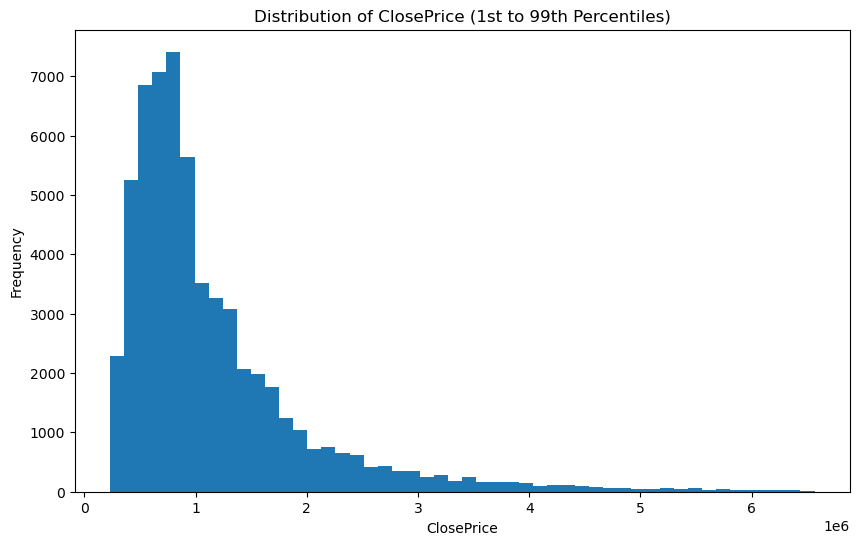

In [93]:
#Graphing the distribution of the target variable ClosePrice using percentiles to limit the x-axis range and avoid extreme outliers
plt.figure(figsize=(10, 6))
# Calculate the 1st and 99th percentiles
lower_bound = plot_df[target_column].quantile(0.01)
upper_bound = plot_df[target_column].quantile(0.99)
plt.hist(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column], bins=50)
#adding lables and title
plt.xlabel(target_column)
plt.ylabel("Frequency")
plt.title(f"Distribution of {target_column} (1st to 99th Percentiles)")

The distribution of the target variable ClosePrice is right-skewed, with a long tail on the right side. The majority of the data points are concentrated on the left side of the distribution, indicating that most properties have lower closing prices, while a smaller number of properties have significantly higher closing prices. This skewness suggests that there may be outliers or extreme values in the dataset that could impact statistical analyses and modeling efforts.

Text(0.5, 1.0, 'Log-Transformed Distribution of ClosePrice (1st to 99th Percentiles)')

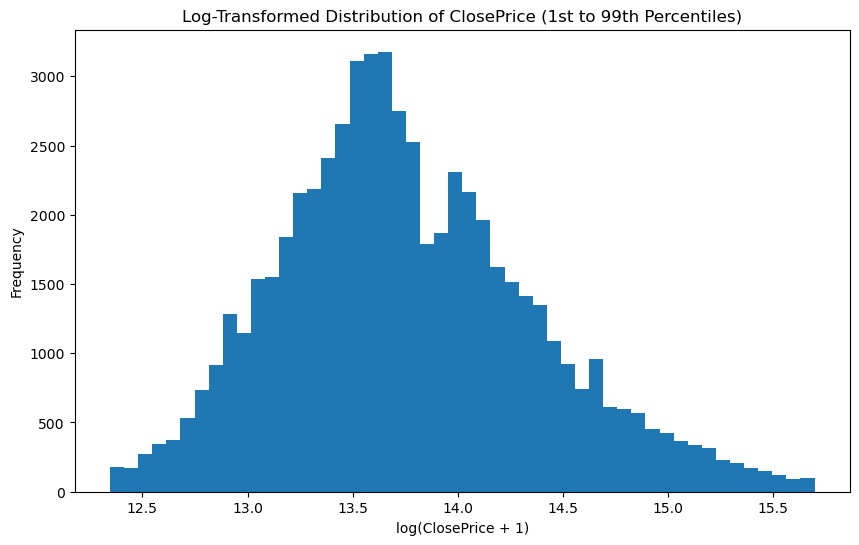

In [94]:
#Apply log transformation to ClosePrice to see if it normalizes the distribution
plt.figure(figsize=(10, 6))
# Apply log transformation, adding 1 to avoid log(0)
log_transformed = np.log1p(plot_df[(plot_df[target_column] >= lower_bound) & (plot_df[target_column] <= upper_bound)][target_column])
plt.hist(log_transformed, bins=50)
plt.xlabel(f"log({target_column} + 1)")
plt.ylabel("Frequency")
plt.title(f"Log-Transformed Distribution of {target_column} (1st to 99th Percentiles)") 

The log transformation reduces the visible skewness of ClosePrice. This is worth comparing during modeling; models do not universally require a normally distributed target.


`ClosePrice` has no missing or non-positive values, but is highley 

## Data Quality Checks

### Duplicate listing checks

Check `df_all` for repeated `ListingKeyNumeric` values before filtering. Matching records exclude `source_file` from equality checks. Differences may indicate updated or conflicting records; file provenance alone does not establish which version is newer.


In [16]:
# Check repeated listing keys across the complete imported dataset.
import pandas as pd
from IPython.display import display

key_column = "ListingKeyNumeric"
comparison_fields = [
    "CloseDate", "ClosePrice", "MlsStatus", "ListPrice", "PropertyType",
    "PropertySubType", "UnparsedAddress", "City", "PostalCode",
]
required_columns = [key_column, "source_file", *comparison_fields]
missing_columns = [column for column in required_columns if column not in df_all.columns]
if missing_columns:
    raise KeyError(f"Duplicate checks require these missing columns: {missing_columns}")

# Missing keys are reported separately; they do not identify a shared listing.
valid_keys = df_all[key_column].notna()
duplicate_mask = valid_keys & df_all.duplicated(key_column, keep=False)
duplicate_rows_full = df_all.loc[duplicate_mask].sort_values(
    [key_column, "source_file"], kind="stable"
)
duplicate_comparison = duplicate_rows_full[[key_column, "source_file", *comparison_fields]]
groups = duplicate_rows_full.groupby(key_column, sort=True)

# Count missing values as a distinct value so missing versus populated is detected.
duplicate_field_counts = groups[comparison_fields].nunique(dropna=False)
duplicate_summary = groups.size().rename("row_count").to_frame()
duplicate_summary["file_count"] = groups["source_file"].nunique(dropna=False)
duplicate_summary["source_files"] = groups["source_file"].agg(
    lambda values: sorted(values.dropna().unique().tolist())
)
duplicate_summary["spans_files"] = duplicate_summary["file_count"].gt(1)
duplicate_summary["differing_fields"] = duplicate_field_counts.apply(
    lambda row: row.index[row.gt(1)].tolist(), axis=1
)
duplicate_summary["important_fields_differ"] = duplicate_field_counts.gt(1).any(axis=1)

# Exact matches compare ALL imported fields, excluding source-file provenance.
record_columns = [column for column in df_all.columns if column != "source_file"]
unique_records = duplicate_rows_full.drop_duplicates(subset=record_columns)
duplicate_summary["distinct_full_records"] = (
    unique_records.groupby(key_column).size().reindex(duplicate_summary.index)
)
duplicate_summary["all_fields_identical"] = duplicate_summary["distinct_full_records"].eq(1)

print(f"Total imported rows: {len(df_all):,}")
print(f"Rows with missing listing keys (excluded from key checks): {(~valid_keys).sum():,}")
print(f"Listing keys shared by multiple rows: {len(duplicate_summary):,}")
print(f"Rows belonging to repeated listing keys: {len(duplicate_rows_full):,}")
print(f"Extra rows beyond one per repeated key: {len(duplicate_rows_full) - len(duplicate_summary):,}")
print(f"Repeated listing keys spanning files: {duplicate_summary['spans_files'].sum():,}")
print(f"Repeated keys with identical records across all fields: {duplicate_summary['all_fields_identical'].sum():,}")
print(f"Repeated keys with differences in selected important fields: {duplicate_summary['important_fields_differ'].sum():,}")
print(f"Exact repeated rows beyond the first (ignoring source_file): {len(duplicate_rows_full) - len(unique_records):,}")

if duplicate_rows_full.empty:
    print("No repeated non-missing listing keys found.")
else:
    print("Summary per repeated listing key:")
    display(duplicate_summary)
    print("Distinct values per important field (>1 indicates a difference):")
    display(duplicate_field_counts)
    print("Comparison rows (all duplicated rows are saved in duplicate_rows_full):")
    display(duplicate_comparison)

    # Show one differing key and one exact-repeat key when available.
    example_keys = []
    for condition in [
        duplicate_summary["important_fields_differ"],
        duplicate_summary["all_fields_identical"],
    ]:
        candidates = duplicate_summary.index[condition]
        if len(candidates):
            example_keys.append(candidates[0])
    if not example_keys:
        example_keys = [duplicate_summary.index[0]]
    for listing_key in dict.fromkeys(example_keys):
        changed = duplicate_summary.at[listing_key, "differing_fields"]
        print(f"Example key {listing_key}; differing important fields: {changed or 'none'}")
        with pd.option_context("display.max_columns", None, "display.max_colwidth", 80):
            display(duplicate_comparison.loc[duplicate_comparison[key_column].eq(listing_key)])


Total imported rows: 122,756
Rows with missing listing keys (excluded from key checks): 0
Listing keys shared by multiple rows: 73
Rows belonging to repeated listing keys: 155
Extra rows beyond one per repeated key: 82
Repeated listing keys spanning files: 67
Repeated keys with identical records across all fields: 6
Repeated keys with differences in selected important fields: 67
Exact repeated rows beyond the first (ignoring source_file): 14
Summary per repeated listing key:


,row_count,file_count,source_files,spans_files,differing_fields,important_fields_differ,distinct_full_records,all_fields_identical
ListingKeyNumeric,,,,,,,,
1107335546,2,2,"[CRMLSSold202601.csv, CRMLSSold202604.csv]",True,[CloseDate],True,2,False
1108963864,2,2,"[CRMLSSold202601.csv, CRMLSSold202604.csv]",True,[CloseDate],True,2,False
1109265068,2,2,"[CRMLSSold202511.csv, CRMLSSold202512.csv]",True,[CloseDate],True,2,False
1109989342,2,2,"[CRMLSSold202512.csv, CRMLSSold202604.csv]",True,"[CloseDate, ClosePrice, ListPrice]",True,2,False
1110678316,2,2,"[CRMLSSold202511.csv, CRMLSSold202512.csv]",True,"[CloseDate, ClosePrice]",True,2,False
...,...,...,...,...,...,...,...,...
1152484608,2,2,"[CRMLSSold202603.csv, CRMLSSold202604.csv]",True,"[CloseDate, ClosePrice]",True,2,False
1153013489,2,2,"[CRMLSSold202603.csv, CRMLSSold202604.csv]",True,[CloseDate],True,2,False
1153086829,2,2,"[CRMLSSold202603.csv, CRMLSSold202604.csv]",True,[CloseDate],True,2,False


Distinct values per important field (>1 indicates a difference):


,CloseDate,ClosePrice,MlsStatus,ListPrice,PropertyType,PropertySubType,UnparsedAddress,City,PostalCode
ListingKeyNumeric,,,,,,,,,
1107335546,2,1,1,1,1,1,1,1,1
1108963864,2,1,1,1,1,1,1,1,1
1109265068,2,1,1,1,1,1,1,1,1
1109989342,2,2,1,2,1,1,1,1,1
1110678316,2,2,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...
1152484608,2,2,1,1,1,1,1,1,1
1153013489,2,1,1,1,1,1,1,1,1
1153086829,2,1,1,1,1,1,1,1,1


Comparison rows (all duplicated rows are saved in duplicate_rows_full):


,ListingKeyNumeric,source_file,CloseDate,ClosePrice,MlsStatus,ListPrice,PropertyType,PropertySubType,UnparsedAddress,City,PostalCode
55870,1107335546,CRMLSSold202601.csv,2026-01-26,695000.0,Closed,699000.0,Residential,SingleFamilyResidence,6324 Autumn Leaf,Jurupa Valley,92509
122615,1107335546,CRMLSSold202604.csv,2026-04-16,695000.0,Closed,699000.0,Residential,SingleFamilyResidence,6324 Autumn Leaf,Jurupa Valley,92509
55782,1108963864,CRMLSSold202601.csv,2026-01-09,577000.0,Closed,569400.0,Residential,SingleFamilyResidence,32025 Corte Cardin,Temecula,92592
122562,1108963864,CRMLSSold202604.csv,2026-04-17,577000.0,Closed,569400.0,Residential,SingleFamilyResidence,32025 Corte Cardin,Temecula,92592
18402,1109265068,CRMLSSold202511.csv,2025-11-03,20000.0,Closed,20000.0,Land,WaterPositionWithLand,188 Clark Way,Palo Verde,92266
...,...,...,...,...,...,...,...,...,...,...,...
112806,1153086829,CRMLSSold202604.csv,2026-04-28,135000.0,Closed,150000.0,ManufacturedInPark,NaN,3620 Moreno 15,La Verne,91750
80259,1153089900,CRMLSSold202603.csv,2026-03-28,1300000.0,Closed,1295000.0,Residential,SingleFamilyResidence,1011 Inspiration Lane,Escondido,92025
112792,1153089900,CRMLSSold202604.csv,2026-04-10,1295000.0,Closed,1295000.0,Residential,SingleFamilyResidence,1011 Inspiration Lane,Escondido,92025
79502,1153224581,CRMLSSold202603.csv,2026-03-28,1610000.0,Closed,1698000.0,Residential,SingleFamilyResidence,3398 Heather Field Drive,Hacienda Heights,91745


Example key 1107335546; differing important fields: ['CloseDate']


,ListingKeyNumeric,source_file,CloseDate,ClosePrice,MlsStatus,ListPrice,PropertyType,PropertySubType,UnparsedAddress,City,PostalCode
55870,1107335546,CRMLSSold202601.csv,2026-01-26,695000.0,Closed,699000.0,Residential,SingleFamilyResidence,6324 Autumn Leaf,Jurupa Valley,92509
122615,1107335546,CRMLSSold202604.csv,2026-04-16,695000.0,Closed,699000.0,Residential,SingleFamilyResidence,6324 Autumn Leaf,Jurupa Valley,92509


Example key 1135672038; differing important fields: none


,ListingKeyNumeric,source_file,CloseDate,ClosePrice,MlsStatus,ListPrice,PropertyType,PropertySubType,UnparsedAddress,City,PostalCode
9639,1135672038,CRMLSSold202511.csv,2025-11-06,137500.0,Closed,350000.0,Land,NaN,0 El Granada Boulevard,El Granada,94018
9640,1135672038,CRMLSSold202511.csv,2025-11-06,137500.0,Closed,350000.0,Land,NaN,0 El Granada Boulevard,El Granada,94018


In [ ]:
# Check California locations in df_filtered using longitude/latitude.
# If needed, install GeoPandas in this notebook's kernel: %pip install geopandas
import json
from urllib.request import urlopen
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

required = ["Latitude", "Longitude"]
missing_columns = [c for c in required if c not in df_filtered.columns]
if missing_columns:
    raise KeyError(f"Missing coordinate columns: {missing_columns}")

# Work on a copy; retain every filtered row, including repeated listings.
location_check = df_filtered.copy()
latitude = pd.to_numeric(location_check["Latitude"], errors="coerce")
longitude = pd.to_numeric(location_check["Longitude"], errors="coerce")
missing_coords = latitude.isna() | longitude.isna()
valid_coords = latitude.between(-90, 90) & longitude.between(-180, 180)
location_check["location_check"] = "missing/non-numeric coordinates"
location_check.loc[~missing_coords & ~valid_coords, "location_check"] = "invalid coordinate range"
location_check.loc[valid_coords, "location_check"] = "awaiting boundary check"

# PublicaMundi's simplified state boundaries: border/coastal flags need review.
boundary_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
with urlopen(boundary_url, timeout=30) as response:
    boundary_data = json.load(response)
california = gpd.GeoDataFrame.from_features(
    [f for f in boundary_data["features"] if f["properties"]["name"] == "California"],
    crs="EPSG:4326",
)
if california.empty:
    raise ValueError("California was not found in the boundary dataset.")

homes_geo = gpd.GeoDataFrame(
    location_check.loc[valid_coords].copy(),
    geometry=gpd.points_from_xy(longitude[valid_coords], latitude[valid_coords]),
    crs="EPSG:4326",  # x = longitude, y = latitude
)
inside = homes_geo.geometry.intersects(california.geometry.iloc[0])
homes_geo["location_check"] = inside.map({
    True: "inside California boundary", False: "outside California boundary"
})
location_check.loc[valid_coords, "location_check"] = homes_geo["location_check"].to_numpy()

counts = location_check["location_check"].value_counts().reindex([
    "inside California boundary", "outside California boundary",
    "missing/non-numeric coordinates", "invalid coordinate range",
], fill_value=0)
location_summary = counts.rename("rows").to_frame()
location_summary["% of df_filtered"] = (counts / len(location_check) * 100).round(2) if len(location_check) else 0
print(f"Checking all {len(location_check):,} rows in df_filtered.")
display(location_summary)
location_issues = location_check.loc[
    location_check["location_check"].ne("inside California boundary")
]
review_columns = [c for c in [
    "ListingKeyNumeric", "source_file", "UnparsedAddress", "City", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude", "location_check",
] if c in location_issues.columns]
print("Rows needing review (first 20; all saved in location_issues):")
display(location_issues[review_columns].head(20))

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
for ax in axes:
    california.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.8)
    if inside.any():
        homes_geo.loc[inside].plot(ax=ax, color="steelblue", markersize=2,
                                   alpha=0.35, label="Inside California")
    if (~inside).any():
        homes_geo.loc[~inside].plot(ax=ax, color="crimson", markersize=12,
                                    alpha=0.8, label="Outside boundary: review")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    if not homes_geo.empty:
        ax.legend(loc="best")
axes[0].set_title("All homes with valid coordinates (including outliers)")
xmin, ymin, xmax, ymax = california.total_bounds
axes[1].set_xlim(xmin - 0.3, xmax + 0.3)
axes[1].set_ylim(ymin - 0.3, ymax + 0.3)
axes[1].set_title("California detail")
plt.tight_layout()
plt.show()

print("Missing/invalid coordinates cannot confirm a home's location.")
print("Outside flags use a simplified boundary; review coastal/border points before excluding rows.")


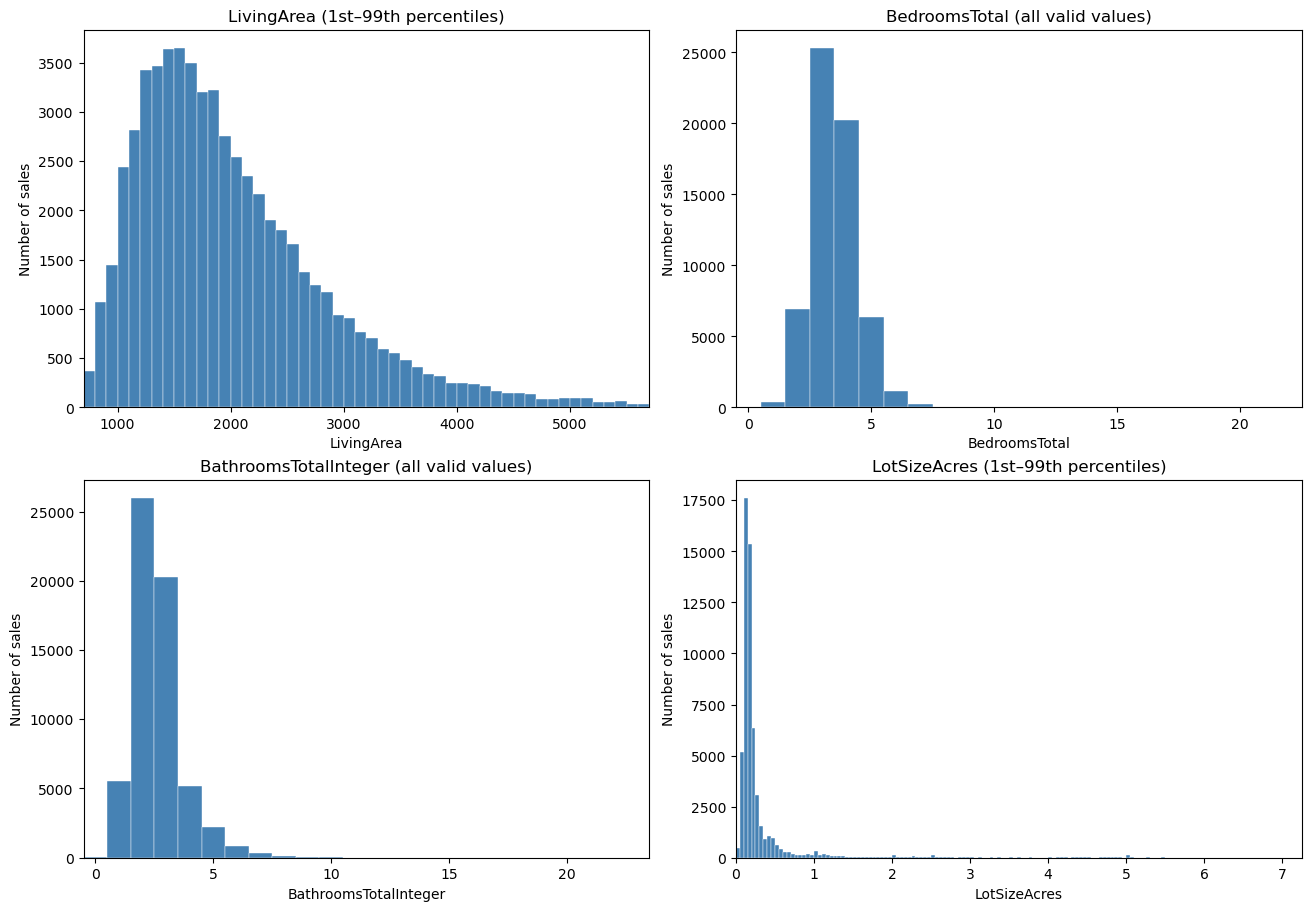

In [99]:
# Smaller bin widths = narrower bars.
bin_widths = {
    "LivingArea": 100,
    "BedroomsTotal": 1,
    "BathroomsTotalInteger": 1,
    "LotSizeAcres": 0.05,
}

count_features = {"BedroomsTotal", "BathroomsTotalInteger"}

fig, axes = plt.subplots(
    2, 2, figsize=(13, 9), constrained_layout=True
)

for ax, (feature, width) in zip(axes.flat, bin_widths.items()):
    values = pd.to_numeric(plot_df[feature], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()

    if values.empty:
        ax.set_title(f"{feature}: no valid values")
        continue

    if feature in count_features:
        # Center bars on whole numbers.
        edges = np.arange(
            np.floor(values.min()) - 0.5,
            np.ceil(values.max()) + 1.5,
            1,
        )
        label = "all valid values"
    else:
        # Limit the displayed range so outliers don't stretch the axis.
        low, high = values.quantile([0.01, 0.99])
        values = values[values.between(low, high)]

        start = np.floor(low / width) * width
        stop = np.ceil(high / width) * width
        edges = np.arange(
            start, max(stop, start + width) + width, width
        )
        label = "1st–99th percentiles"

    ax.hist(
        values,
        bins=edges,
        rwidth=1.0,  # Bars touch.
        color="steelblue",
        edgecolor="white",
        linewidth=0.3,
    )
    ax.set_title(f"{feature} ({label})")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of sales")
    ax.set_xlim(edges[0], edges[-1])

plt.show()

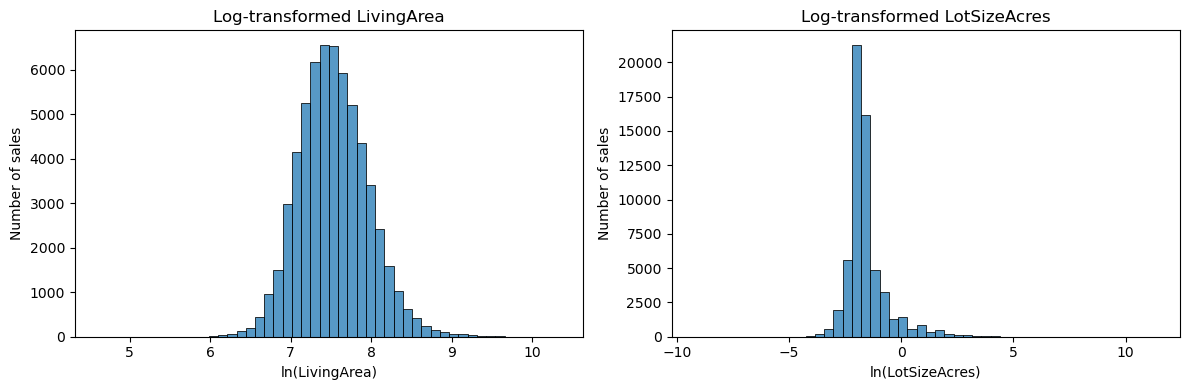

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feature in zip(axes, ["LivingArea", "LotSizeAcres"]):
    values = pd.to_numeric(plot_df[feature], errors="coerce")
    positive = values[values.gt(0) & np.isfinite(values)]

    sns.histplot(np.log(positive), bins=50, ax=ax)
    ax.set_title(f"Log-transformed {feature}")
    ax.set_xlabel(f"ln({feature})")
    ax.set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

After looking at the distributions of the features, it seems that log transformation is appropriate for LivingArea and LotSizeAcres, but not for BedroomsTotal and BathroomsTotalInteger. The latter two are count variables and their distributions are already discrete and bounded, so log transformation would not be meaningful. Furthermore, the log transformation of LivingArea and LotSizeAcres helps to reduce the skewness in their distributions, making them more suitable for modeling. 

Text(0.5, 1.0, 'Boxplot of ClosePrice')

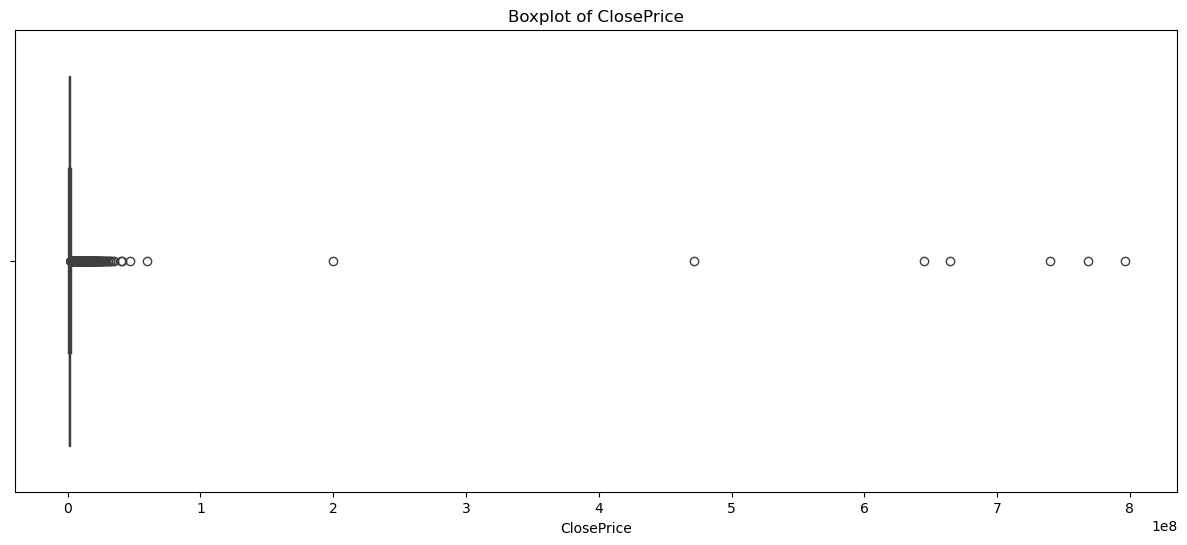

In [121]:
# Checking outliers in the target variable ClosePrice using boxplot
plt.figure(figsize=(15, 6))
sns.boxplot(x=plot_df[target_column])
plt.title(f"Boxplot of {target_column}")

<Axes: >

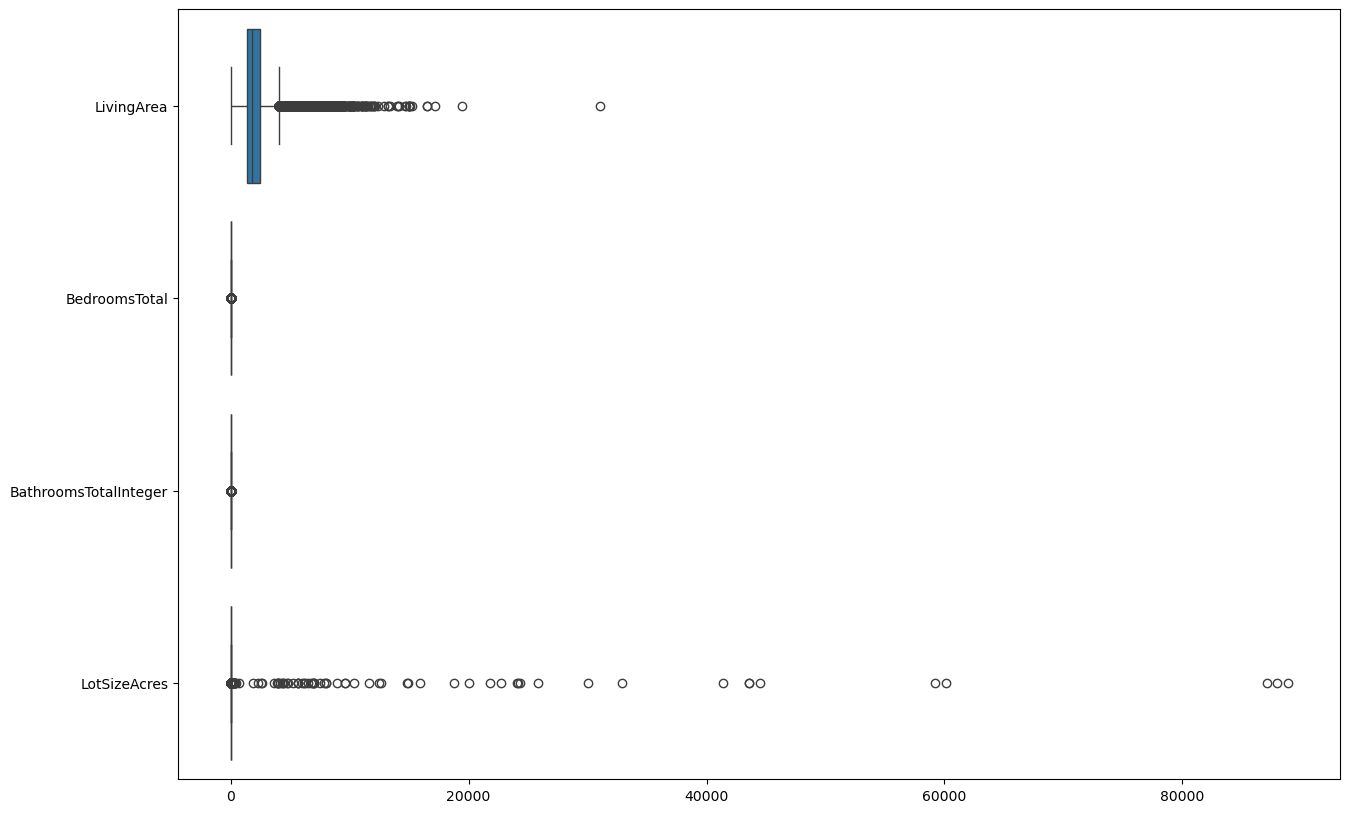

In [125]:
#checking outlier in feature columns using boxplot, horizontal boxplots for better readability
plt.figure(figsize=(15, 10))
sns.boxplot(data=plot_df[feature_columns], orient="h")

Quick notes on data quality issues:
1. ClosePrice has some null and non-positive values, which may need to be addressed in preprocessing.
2. LivingArea, BedroomsTotal, BathroomsTotalInteger, and LotSizeAcres also have some extreme outliers, which may affect model performance and should be considered for preprocessing or feature engineering.
3. The distributions of LivingArea and LotSizeAcres are highly skewed, suggesting that log transformation may be beneficial for modeling. 

<Axes: >

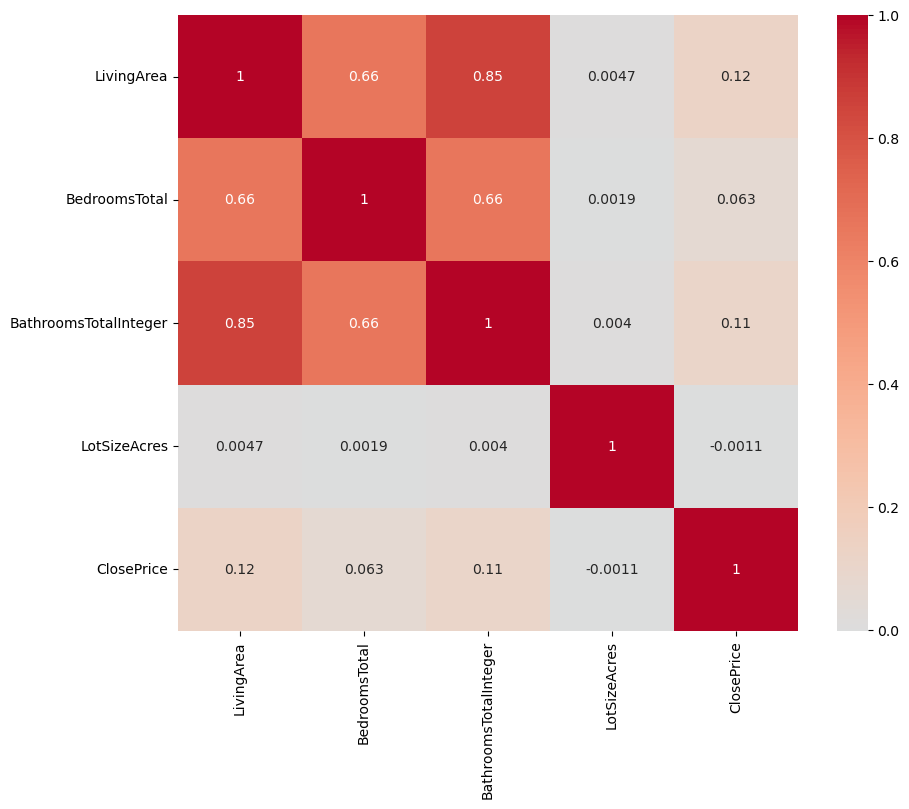

In [128]:
#Now that we did some data quality check, we can move onto seeing the correlation between the features and the target variable ClosePrice. We can use a heatmap to visualize the correlation matrix.
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

This heatmap shows that there is a strong positive correlation between LivingArea and ClosePrice, as well as a moderate positive correlation between LotSizeAcres and ClosePrice. BedroomsTotal and BathroomsTotalInteger show weaker correlations with ClosePrice. This suggests that LivingArea and LotSizeAcres may be more important features to consider when predicting ClosePrice.

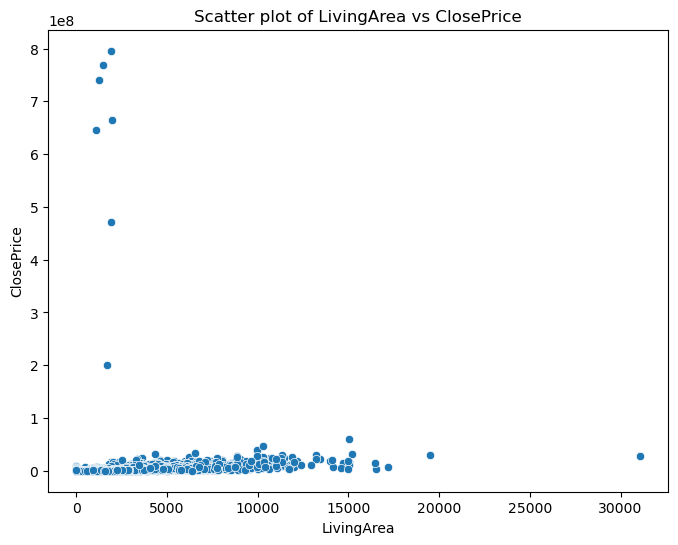

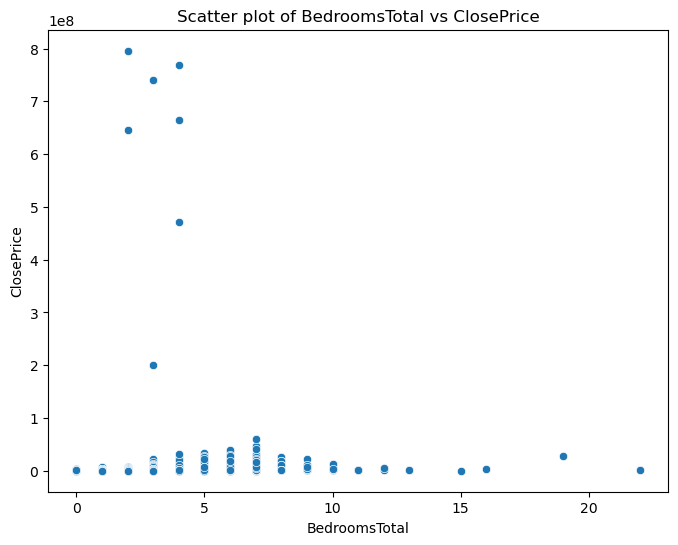

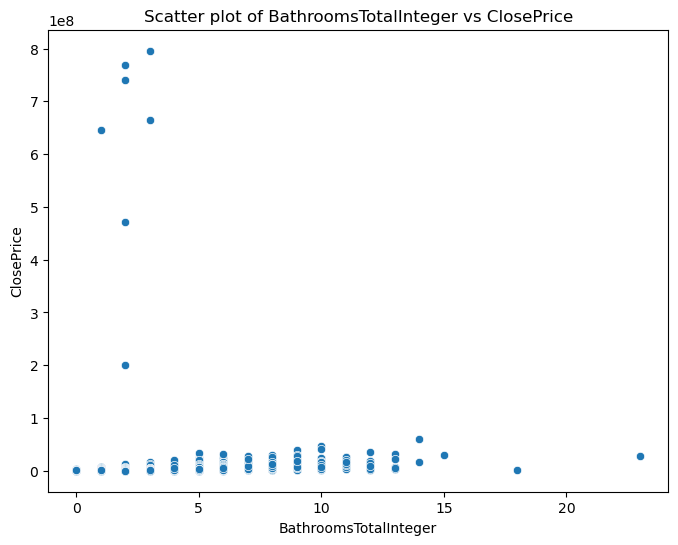

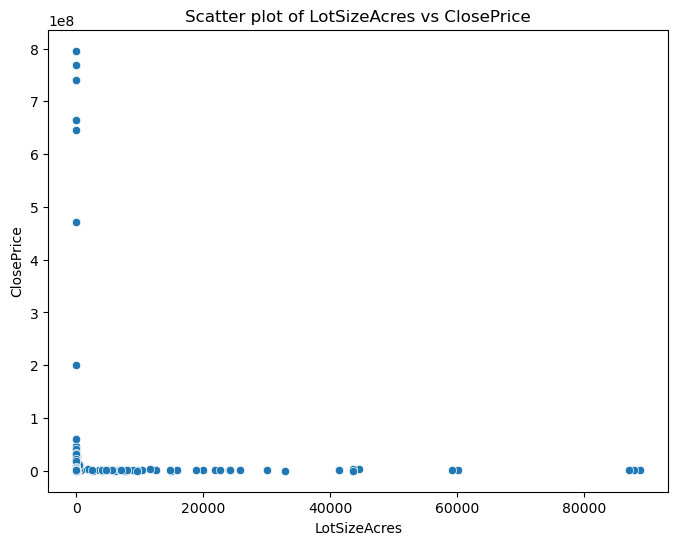

In [130]:
#lets also check the correlation between the features and target varibale using scatterplots respectively to see if there is any linear relationship between the features and the target variable ClosePrice
for feature in feature_columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=plot_df[feature], y=plot_df[target_column])
    plt.title(f"Scatter plot of {feature} vs {target_column}")
    plt.xlabel(feature)
    plt.ylabel(target_column)
    plt.show()

## Feature comparisons with ClosePrice

Compact correlations and missing rates followed by continuous-feature scatterplots and count-feature price boxplots. Plots cap values at the 99th percentile for readability; count-feature tails are grouped. Correlations use uncapped values. Geography may have nonlinear relationships with price, and association fees depend on billing frequency.


In [ ]:
# Compact feature comparisons: uncapped correlations, capped plots.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

fee_column = next((c for c in ["AssociationFee", "AssociationFees"] if c in df_filtered), "AssociationFee")
continuous = ["LivingArea", "LotSizeSquareFeet", "YearBuilt", "Latitude", "Longitude", fee_column]
counts = ["BedroomsTotal", "BathroomsTotalInteger", "GarageSpaces", "ParkingTotal", "Stories"]
requested = continuous + counts
available = [c for c in requested if c in df_filtered]
missing = [c for c in requested if c not in df_filtered]
if missing:
    print(f"Unavailable columns skipped: {missing}")

numeric = df_filtered[["ClosePrice", *available]].apply(
    pd.to_numeric, errors="coerce"
).replace([np.inf, -np.inf], np.nan)
for column, bounds in {"Latitude": (-90, 90), "Longitude": (-180, 180)}.items():
    if column in numeric:
        numeric.loc[~numeric[column].between(*bounds), column] = np.nan
valid_prices = numeric["ClosePrice"].gt(0)
analysis = numeric.loc[valid_prices].copy()

rows = []
for feature in available:
    pairs = analysis[[feature, "ClosePrice"]].dropna()
    sufficient = len(pairs) >= 3 and pairs.nunique().gt(1).all()
    rows.append({
        "feature": feature,
        "pearson_corr": pairs[feature].corr(pairs["ClosePrice"], method="pearson") if sufficient else np.nan,
        "spearman_corr": pairs[feature].corr(pairs["ClosePrice"], method="spearman") if sufficient else np.nan,
        "missing_rate": numeric[feature].isna().mean(),
    })
if rows:
    feature_correlations = pd.DataFrame(rows).set_index("feature")
    feature_correlations = feature_correlations.loc[
        feature_correlations["spearman_corr"].abs().sort_values(ascending=False, na_position="last").index
    ]
    display(feature_correlations.style.format("{:.6f}", na_rep="—"))
    print("Missing rate is a fraction of all filtered rows (0.10 = 10%). Correlations use uncapped valid pairs.")

# Capping is visual only; df_filtered and the correlation inputs remain unchanged.
plot_data = analysis.copy()
price_cap = plot_data["ClosePrice"].quantile(0.99)
plot_data["ClosePrice"] = plot_data["ClosePrice"].clip(upper=price_cap)
for feature in available:
    plot_data[feature] = plot_data[feature].clip(upper=plot_data[feature].quantile(0.99))

plot_features = [c for c in continuous + counts if c in available]
if plot_features and not plot_data.empty:
    with sns.axes_style("whitegrid"):
        fig, axes = plt.subplots(
            math.ceil(len(plot_features) / 3), 3,
            figsize=(16, 4 * math.ceil(len(plot_features) / 3)),
            squeeze=False, constrained_layout=True,
        )
        for ax, feature in zip(axes.flat, plot_features):
            pairs = plot_data[[feature, "ClosePrice"]].dropna()
            if pairs.empty:
                ax.set_title(f"{feature}: no valid pairs")
                continue
            if feature in continuous:
                ax.scatter(pairs[feature], pairs["ClosePrice"],
                           s=5, alpha=0.15, color="#4c72b0", rasterized=True)
                ax.set_title(f"ClosePrice vs {feature}")
                ax.set_xlabel(f"{feature} (capped at 99th pct)")
            else:
                # Keep original count categories below the cap; place the tail
                # into a labeled upper group instead of inventing fractional counts.
                raw = analysis.loc[pairs.index, feature]
                cap = analysis[feature].quantile(0.99)
                below = sorted(raw.loc[raw.le(cap)].unique())
                label_map = {v: f"{v:g}" for v in below}
                order = list(label_map.values())
                pairs = pairs.copy()
                pairs["count_group"] = raw.map(label_map)
                if raw.gt(cap).any():
                    tail_label = f">{cap:g}"
                    pairs.loc[raw.gt(cap), "count_group"] = tail_label
                    order.append(tail_label)
                sns.boxplot(data=pairs, x="count_group", y="ClosePrice",
                            order=order, color="#4c72b0", showfliers=False, ax=ax)
                ax.set_title(f"ClosePrice by {feature}")
                ax.set_xlabel(f"{feature} (upper 1% grouped)")
                ax.tick_params(axis="x", rotation=45)
            ax.set_ylabel("ClosePrice (capped at 99th pct)")
            ax.ticklabel_format(axis="y", style="sci", scilimits=(6, 6))
        for ax in list(axes.flat)[len(plot_features):]:
            ax.set_visible(False)
        plt.show()
else:
    print("No valid feature/price data to plot.")

if fee_column in available and "AssociationFeeFrequency" in df_filtered:
    print("Review fee billing frequency before comparing association-fee amounts:")
    display(df_filtered["AssociationFeeFrequency"].value_counts(dropna=False).rename("rows").to_frame())


## Key takeaways and next steps

- **Project scope:** The analysis focuses on residential single-family sales. Compare retained row counts and missing rates with the full imports; filtering changes the population rather than filling missing values.
- **Price distribution:** `ClosePrice` is right-skewed. Log price is worth evaluating during modeling, but a normally distributed target is not a requirement for every model. Percentile caps in the comparison plots are visual aids, not a cleaning rule.
- **Feature relationships:** Compare Pearson and Spearman correlations alongside the plots. Differences between them can suggest outlier sensitivity or nonlinear relationships. Low marginal correlation, especially for location, does not establish that a feature is unhelpful.
- **Missing data:** Entirely empty fields provide no usable information in this sample. Choose imputation or exclusion rules for partially missing features during preprocessing, and distinguish missing values from meaningful zeros.
- **Repeated listings:** Review exact repeats separately from records whose important fields differ. Establish a justified deduplication rule before modeling, and keep the same listing key out of both training and evaluation sets.
- **Location:** Review `location_summary` and `location_issues` before concluding that every home is in California. Missing coordinates cannot verify location; points near the simplified boundary need individual review.
- **Feature context:** Association-fee amounts require consistent billing periods. Also consider the meaning and plausibility of zero or extreme values in area, parking, bedrooms, and stories.